### Import Libraries
✅ Explanation:

- NumPy → create synthetic data

- Pandas → store data in table form

- Matplotlib → visualization

- LinearRegression → model training

- train_test_split → split data into train/test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



### Create Synthetic/Artificial Dataset Using Numpy
✅ Explanation:

X is your input feature (like hours studied)

y is your output (like marks)

3*X + 5 is the true linear relation

np.random.randn() adds random noise (real-world data is never perfect)

formula : y=3x+5+noise

In [ ]:
np.random.seed(42)                  #for same random output every time
#Generate input feature (X)
X = np.random.rand(100,1)*10        #100 values between 0 to 10
#Generate output target (y)
y = 3*X+5+np.random.rand(100,1)*2   #adding noise cause real world data isn't too accurate

### Convert into DataFrame

In [3]:
data = pd.DataFrame({
    "X":X.flatten(),
    "y":y.flatten()
})
#flatten() converts 2D array into 1D so pandas can display properly
print(data.head(10))

          X          y
0  3.745401  16.299062
1  9.507143  34.794250
2  7.319939  27.588530
3  5.986585  23.976896
4  1.560186  11.495692
5  1.559945  10.178420
6  0.580836   7.563274
7  8.661761  32.496387
8  6.011150  23.491047
9  7.080726  26.396137


### Visualize Dataset

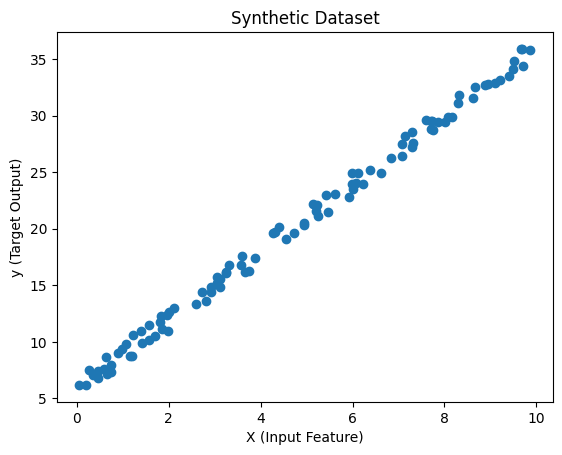

In [33]:
plt.scatter(X,y)
plt.xlabel("X (Input Feature)")
plt.ylabel("y (Target Output)")
plt.title("Synthetic Dataset")
plt.show()

### Split data into Training & Testing
✅ Explanation:

80% training

20% testing

Testing is needed to check if model works on unseen data.

In [5]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

### Train Linear Regression Model
✅ Explanation:

.fit() trains the model.

It finds best values of:

slope (weight)

intercept (bias)

In [6]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Print Model Parameters
✅ Explanation:

coef_ gives slope (m)

intercept_ gives constant term (c)

Equation becomes:

y=mx+c

In [7]:
print("Slope (Coefficient): ", model.coef_[0][0])
print("Intercept: ", model.intercept_[0])

Slope (Coefficient):  2.9882784629608348
Intercept:  6.0638890241314645


### Perform Predictions
✅ Explanation:

This predicts output values for testing dataset.

So now we have:

y_test = actual output

y_pred = predicted output

In [8]:
y_pred = model.predict(X_test)

### Residual Calculation
📌 Residual = Actual - Predicted
residuals = y_test - y_pred

✅ Explanation:

Residual tells the error for each data point.

If residual is small → prediction is good

If residual is large → model prediction is poor

In [9]:
residuals = y_test - y_pred

### Display Actual vs Predicted vs Residuals

In [10]:
result = pd.DataFrame({
    "Actual" : y_test.flatten(),
    "Predicted" : y_pred.flatten(),
    "Residuals" : residuals.flatten()
})
print(result.head(10))

      Actual  Predicted  Residuals
0   8.661429   7.963190   0.698240
1  32.823726  32.803822   0.019904
2  29.522472  29.140713   0.381759
3  24.949442  25.861900  -0.912457
4  13.333080  13.796955  -0.463875
5  20.148139  19.216871   0.931268
6  14.400346  14.793985  -0.393638
7  31.575235  31.855823  -0.280587
8   6.197038   6.679011  -0.481973
9  16.299062  17.256191  -0.957129


### Plot Best Fit Line
✅ Explanation:

Dots represent actual and predicted points.

If model is good → predicted points will be near actual points.

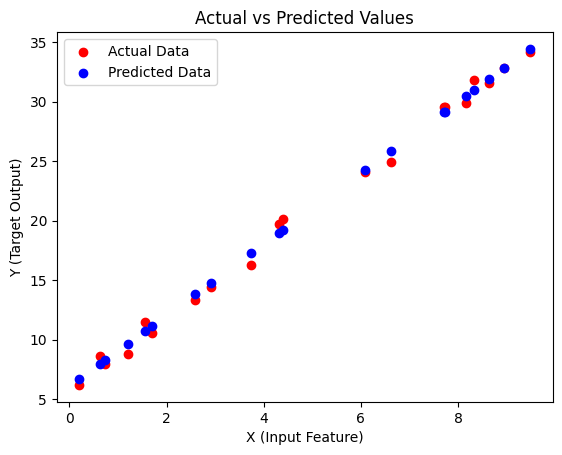

In [11]:
plt.scatter(X_test,y_test,label="Actual Data",color = "red")
plt.scatter(X_test,y_pred,label="Predicted Data", color = "blue")
plt.xlabel("X (Input Feature)")
plt.ylabel("Y (Target Output)")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


### Residual Plot(Important for understanding errors)
✅ Explanation:

Red line = zero error line

If residuals are randomly scattered around 0 → model is good

If pattern exists → model is missing some relation

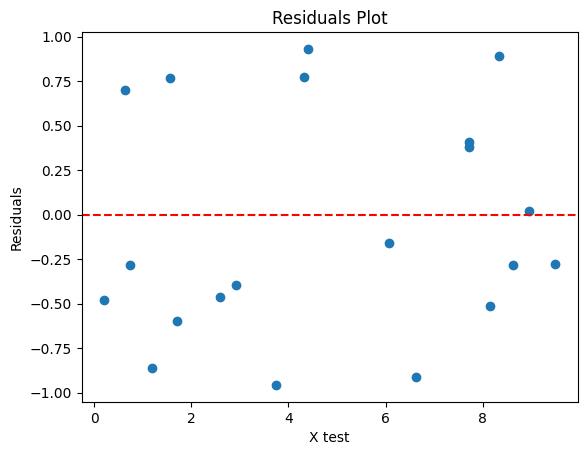

In [12]:
plt.scatter(X_test,residuals)
plt.axhline(y=0,color="red",linestyle="--") #this draws a horizontal reference line at residual = 0
plt.xlabel("X test")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

✅ Quick Summary (Notebook Explanation Style)

🔹 Prediction

Prediction means the model calculates output using learned equation:

predicted_value = mx+c

🔹 Residual

Residual shows error difference:

Residual=Actual−Predicted

Residual helps us understand how accurate the model is.

### Calculate MAE,MSE,RMSE,R^2

- MAE : Mean Absolute Error(average absolute difference between actual and predicted values.)
- MSE : Mean Squared Error(Squares the errors, so large mistakes gets heavy penalty)
- RMSE : Root Mean Squared Error(square root of MSE, so error comes back to the same unit as output)
- R^2 : Coefficient Of Determination(It tells how much variance is explained by the model.

✔ R² = 1 → perfect model

✔ R² = 0 → useless model

✔ R² negative → worst model)

In [13]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test,y_pred)
print("MAE :",MAE)
print("MSE :",MSE)
print("RMSE :",RMSE)
print("R^2 :",r2)


MAE : 0.5529692359922458
MSE : 0.3817721387903588
RMSE : 0.617877122727779
R^2 : 0.9957523436728657


### Create a clean Evaluation Table

In [14]:
metrics = pd.DataFrame({
    "Metric": ["MAE","MSE","RMSE","R^2 Score"],
    "Value": [MAE,MSE,RMSE,r2],
})
print(metrics)

      Metric     Value
0        MAE  0.552969
1        MSE  0.381772
2       RMSE  0.617877
3  R^2 Score  0.995752


## Visualization (Important for Notebook Output)

### (A) Actual vs Predicted Line Graph

If the predicted points overlap actual points → model is strong.

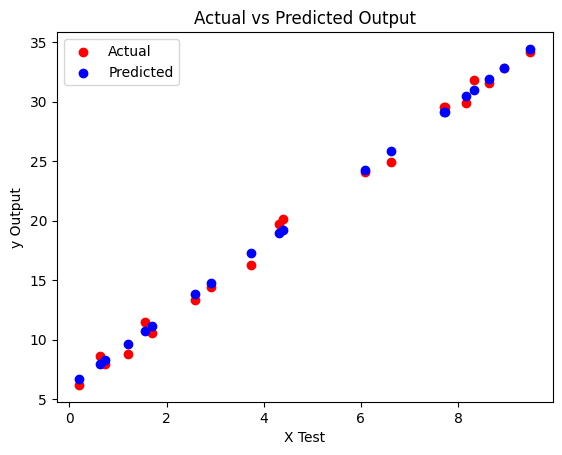

In [15]:
plt.scatter(X_test, y_test, label="Actual",color = "red")
plt.scatter(X_test, y_pred, label="Predicted", color = "blue")

plt.xlabel("X Test")
plt.ylabel("y Output")
plt.title("Actual vs Predicted Output")
plt.legend()
plt.show()


### (B) Residual Distribution Plot

If residual points are randomly spread around 0 → model is correct.

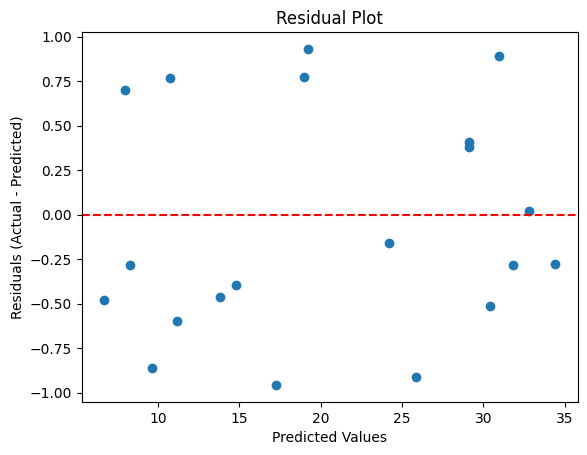

In [16]:
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color="red",linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

### (C) Histogram of Residuals

Residuals should be mostly centered around 0.

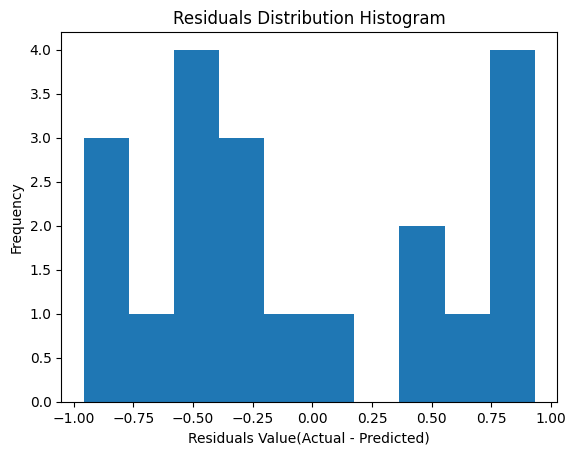

In [17]:
plt.hist(residuals,bins=10)
plt.xlabel("Residuals Value(Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residuals Distribution Histogram")
plt.show()

# Linear Regression Full Pipeline
This notebook demonstrates the complete pipeline of Linear Regression using a synthetic dataset.
## Step 1: Dataset Creation
Synthetic dataset is created using NumPy with random noise to simulate real-world data.
## Step 2: Train-Test Split
Dataset is split into training and testing sets to evaluate model performance.
## Step 3: Model Training
Linear Regression model is trained using sklearn.
## Step 4: Model Evaluation
Evaluation is done using MAE, MSE, RMSE and R² Score.
## Step 5: Residual Analysis
Residual plots are used to check how much error is present in predictions.
## Conclusion
The Linear Regression model was successfully trained on synthetic data.
The evaluation metrics (MAE, MSE, RMSE, R²) were calculated.
Residual plots showed how prediction errors are distributed, helping validate model accuracy.


# SESSION 2- Scaling with Linear Regression

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [19]:
model_no_scaling = LinearRegression()
model_no_scaling.fit(X_train, y_train)

y_pred_no_scaling = model_no_scaling.predict(X_test)


## Evaluate Model Without Scaling

In [20]:
mae_no = mean_absolute_error(y_test, y_pred_no_scaling)
mse_no = mean_squared_error(y_test, y_pred_no_scaling)
rmse_no = np.sqrt(mse_no)
r2_no = r2_score(y_test, y_pred_no_scaling)

print("WITHOUT Scaling Metrics:")
print("MAE :", mae_no)
print("MSE :", mse_no)
print("RMSE:", rmse_no)
print("R²  :", r2_no)


WITHOUT Scaling Metrics:
MAE : 0.5529692359922458
MSE : 0.3817721387903588
RMSE: 0.617877122727779
R²  : 0.9957523436728657


## Apply StandardScaler(Standardization)
StandardScaler works on X values only

Explanation:

fit_transform() learns mean and std from training data and transforms it

transform() applies same scaling to test data
(never fit test data because it causes data leakage)

In [21]:
scaler_standard = StandardScaler()

X_train_std = scaler_standard.fit_transform(X_train)
X_test_std = scaler_standard.transform(X_test)


## Train Linear Regression with StandardScaler

In [22]:
model_std = LinearRegression()
model_std.fit(X_train_std, y_train)
y_pred_std = model_std.predict(X_test_std)

## Evaluate StandardScaler Model

In [23]:
mae_std = mean_absolute_error(y_test,y_pred_std)
mse_std = mean_squared_error(y_test,y_pred_std)
rmse_std = np.sqrt(mse_std)
r2_std = r2_score(y_test, y_pred_std)

print("\nWITH StandardScaler Metrics:")
print("MAE :", mae_std)
print("MSE :", mse_std)
print("RMSE:", rmse_std)
print("R²  :", r2_std)


WITH StandardScaler Metrics:
MAE : 0.5529692359922459
MSE : 0.38177213879035876
RMSE: 0.617877122727779
R²  : 0.9957523436728657


## Apply MinMaxScaler(Normalization)

In [24]:
scaler_minmax= MinMaxScaler()

X_train_mm = scaler_minmax.fit_transform(X_train)
X_test_mm = scaler_minmax.transform(X_test)


## Train Linear Regression With MinMaxScaler

In [25]:
model_mm = LinearRegression()
model_mm.fit(X_train_mm,y_train)

y_pred_mm = model_mm.predict(X_test_mm)

## Evaluate MinMaxScaler Model

In [26]:
mae_mm = mean_absolute_error(y_test,y_pred_mm)
mse_mm = mean_squared_error(y_test,y_pred_mm)
rmse_mm = np.sqrt(mse_mm)
r2_mm = r2_score(y_test,y_pred_mm)

print("\nWITH MinMaxScaler Metrics:")
print("MAE :", mae_mm)
print("MSE :", mse_mm)
print("RMSE:", rmse_mm)
print("R²  :", r2_mm)


WITH MinMaxScaler Metrics:
MAE : 0.5529692359922457
MSE : 0.3817721387903588
RMSE: 0.617877122727779
R²  : 0.9957523436728657


## Final Comparison

In [27]:
comparison = pd.DataFrame({
    "Model":["No scaling","StandardScaler","MinMaxScaler"],
    "MAE":[mae_no,mae_std,mae_mm],
    "MSE":[mse_no,mse_std,mse_mm],
    "RMSE":[rmse_no,rmse_std,rmse_mm],
    "R^2 Score":[r2_no,r2_std,r2_mm],
})
print("Comparison Table:\n")
print(comparison)

Comparison Table:

            Model       MAE       MSE      RMSE  R^2 Score
0      No scaling  0.552969  0.381772  0.617877   0.995752
1  StandardScaler  0.552969  0.381772  0.617877   0.995752
2    MinMaxScaler  0.552969  0.381772  0.617877   0.995752


## Important
In LinearRegression from sklearn, scaling usually does not change performance much because it uses a mathematical closed-form solution.

But scaling is still important for:

Gradient Descent based regression

Logistic regression

SVM, KNN

Neural networks

# SESSION 3 (Matplotlib) - Visualisations

## Scatter Plot + Regression Line(No Scaling Model)

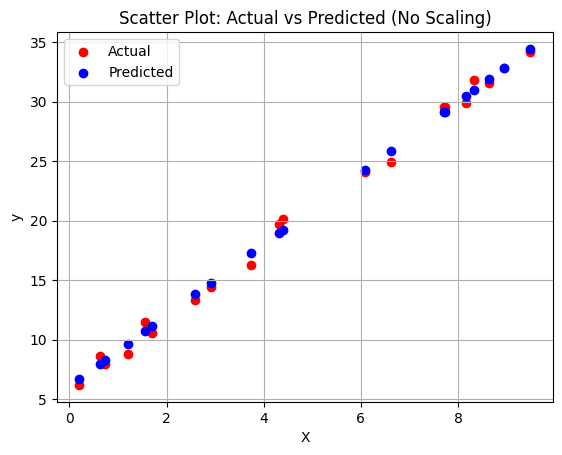

In [28]:
plt.scatter(X_test,y_test,label="Actual",color = "red")
plt.scatter(X_test,y_pred_no_scaling,label="Predicted",color = "blue")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter Plot: Actual vs Predicted (No Scaling)")
plt.legend()
plt.grid(True)
plt.show()

## (B) Regression Line Plot (Best Look)

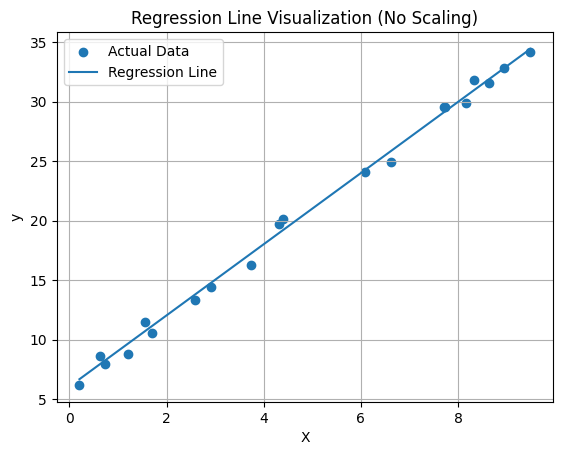

In [ ]:
sorted_index = np.argsort(X_test.flatten()) #argsort:It gives the indexes that would sort the array.
#flatten():It converts a 2D array into 1D array.
X_sorted = X_test.flatten()[sorted_index]   #Now we use those indexes to actually sort X values.
y_pred_sorted = y_pred_no_scaling.flatten()[sorted_index]   #Now we use those indexes to actually sort X values.

plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_sorted, y_pred_sorted, label="Regression Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Line Visualization (No Scaling)")
plt.legend()
plt.grid(True)
plt.show()

## (C) Residual Plot
If residuals are randomly spread around 0 → good model

If curve pattern exists → model is missing relationship

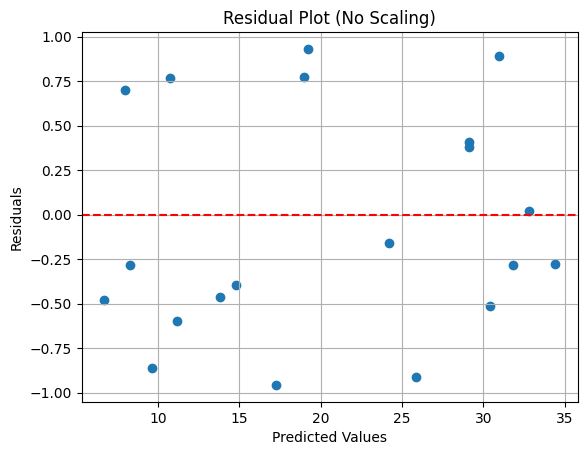

In [30]:
residuals_no = y_test-y_pred_no_scaling
plt.scatter(y_pred_no_scaling, residuals_no)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (No Scaling)")
plt.grid(True)
plt.show()

## (D) Residual Plot for StandardScaler Model

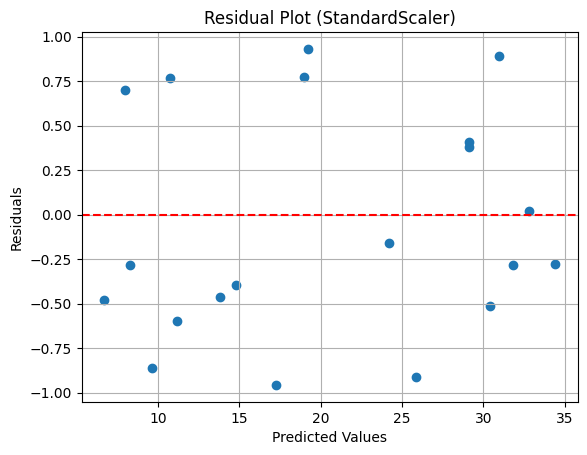

In [31]:
residuals_std = y_test - y_pred_std
plt.scatter(y_pred_std, residuals_std)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (StandardScaler)")
plt.grid(True)
plt.show()

## (E) Residual Plot for MinMaxScaler Model

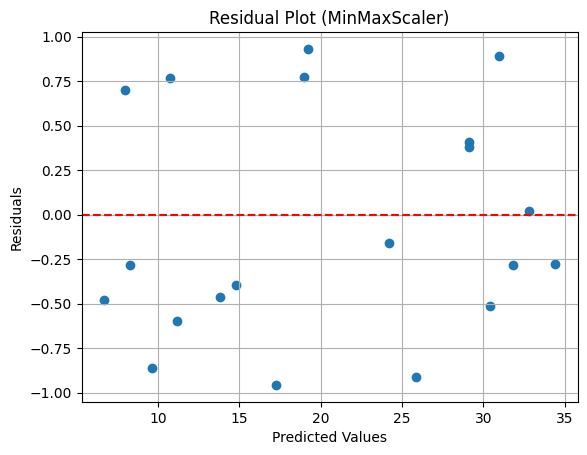

In [32]:
residuals_mm = y_test-y_pred_mm
plt.scatter(y_pred_mm, residuals_mm)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (MinMaxScaler)")
plt.grid(True)
plt.show()

# Scaling + Regression Visualization
This notebook demonstrates feature scaling techniques and compares regression performance with and without scaling.

## Step 1: Synthetic Dataset Creation
A synthetic dataset is generated using NumPy with added random noise to simulate real-world data.

## Step 2: Train-Test Split
Dataset is split into training and testing sets to evaluate the model on unseen data.

## Step 3: Linear Regression Without Scaling
Model is trained directly on raw features and evaluated using regression metrics.

## Step 4: Standardization using StandardScaler
StandardScaler converts data to mean = 0 and std = 1, improving gradient descent efficiency.

## Step 5: Normalization using MinMaxScaler
MinMaxScaler converts feature values into the range 0 to 1.

## Step 6: Visualization
Scatter plots, regression line plots, and residual plots are used to analyze model predictions.

## Conclusion
Feature scaling helps algorithms that rely on gradient descent and distance calculations.
In Linear Regression, scaling may not significantly change performance, but it is essential for stable training in many ML models.
